In [ ]:
import time
import pandas as pd
import nltk as nltk
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

# Load the filtered hotel reviews from CSV
df = pd.read_csv('../../../archive/Hotel_Reviews_Filtered.csv')

# You code will be added here


# Finally remember to save the hotel reviews with new NLP data added
# print("Saving results to Hotel_Reviews_NLP.csv")
# df.to_csv(r'../../../archive/Hotel_Reviews_NLP.csv', index = False)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/lisa/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Saving results to Hotel_Reviews_NLP.csv


In [4]:
from nltk.corpus import stopwords
nltk.download('stopwords')

start = time.time()
cache = set(stopwords.words("english"))
def remove_stopwords(review):
    text = " ".join([word for word in review.split() if word not in cache])
    return text

# Remove the stop words from both columns
df.Negative_Review = df.Negative_Review.apply(remove_stopwords)   
df.Positive_Review = df.Positive_Review.apply(remove_stopwords)

[nltk_data] Downloading package stopwords to /home/lisa/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [5]:
df.head(5)

,Hotel_Address,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Total_Number_of_Reviews,Positive_Review,Reviewer_Score,Tags,Leisure_trip,Couple,Solo_traveler,Business_trip,Group,Family_with_young_children,Family_with_older_children,With_a_pet
0,"Amsterdam, Netherlands",7.8,Hotel Arena,Russia,I angry made post available via possible sites...,405,Only park outside hotel beautiful,2.9,"Leisure trip, Couple, Duplex Double Room, Sta...",1,1,0,0,0,0,0,0
1,"Amsterdam, Netherlands",7.8,Hotel Arena,Ireland,No Negative,405,No real complaints hotel great great location ...,7.5,"Leisure trip, Couple, Duplex Double Room, Sta...",1,1,0,0,0,0,0,0
2,"Amsterdam, Netherlands",7.8,Hotel Arena,Australia,Rooms nice elderly bit difficult rooms two sto...,405,Location good staff ok It cute hotel breakfast...,7.1,"Leisure trip, Family with young children, Dup...",1,0,0,0,0,1,0,0
3,"Amsterdam, Netherlands",7.8,Hotel Arena,United Kingdom,My room dirty I afraid walk barefoot floor loo...,405,Great location nice surroundings bar restauran...,3.8,"Leisure trip, Solo traveler, Duplex Double Ro...",1,0,1,0,0,0,0,0
4,"Amsterdam, Netherlands",7.8,Hotel Arena,New Zealand,You When I booked company line showed pictures...,405,Amazing location building Romantic setting,6.7,"Leisure trip, Couple, Suite, Stayed 2 nights,...",1,1,0,0,0,0,0,0


In [6]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Create the vader sentiment analyser (there are others in NLTK you can try too)
vader_sentiment = SentimentIntensityAnalyzer()
# Hutto, C.J. & Gilbert, E.E. (2014). VADER: A Parsimonious Rule-based Model for Sentiment Analysis of Social Media Text. Eighth International Conference on Weblogs and Social Media (ICWSM-14). Ann Arbor, MI, June 2014.

# There are 3 possibilities of input for a review:
# It could be "No Negative", in which case, return 0
# It could be "No Positive", in which case, return 0
# It could be a review, in which case calculate the sentiment
def calc_sentiment(review):    
    if review == "No Negative" or review == "No Positive":
        return 0
    return vader_sentiment.polarity_scores(review)["compound"]    

In [7]:
# Add a negative sentiment and positive sentiment column
print("Calculating sentiment columns for both positive and negative reviews")
start = time.time()
df["Negative_Sentiment"] = df.Negative_Review.apply(calc_sentiment)
df["Positive_Sentiment"] = df.Positive_Review.apply(calc_sentiment)
end = time.time()
print("Calculating sentiment took " + str(round(end - start, 2)) + " seconds")

Calculating sentiment columns for both positive and negative reviews
Calculating sentiment took 61.28 seconds


In [8]:
df = df.sort_values(by=["Negative_Sentiment"], ascending=True)
print(df[["Negative_Review", "Negative_Sentiment"]])
df = df.sort_values(by=["Positive_Sentiment"], ascending=True)
print(df[["Positive_Review", "Positive_Sentiment"]])

                                          Negative_Review  Negative_Sentiment
186584  So bad experience memories I hotel The first n...             -0.9920
129503  First charged twice room booked booking second...             -0.9896
307286  The staff Had bad experience even booking Janu...             -0.9889
201953  Everything DO NOT STAY AT THIS HOTEL I never i...             -0.9886
452092  No WLAN room Incredibly rude restaurant staff ...             -0.9884
...                                                   ...                 ...
138365  Wifi terribly slow I speed test network upload...              0.9938
79215   I find anything hotel first I walked past hote...              0.9938
278506  The property great location There bakery next ...              0.9945
339189  Guys I like hotel I wish return next year Howe...              0.9948
480509  I travel lot far visited countless number hote...              0.9957

[515738 rows x 2 columns]
                                     

In [9]:
# Reorder the columns (This is cosmetic, but to make it easier to explore the data later)
df = df.reindex(["Hotel_Name", "Hotel_Address", "Total_Number_of_Reviews", "Average_Score", "Reviewer_Score", "Negative_Sentiment", "Positive_Sentiment", "Reviewer_Nationality", "Leisure_trip", "Couple", "Solo_traveler", "Business_trip", "Group", "Family_with_young_children", "Family_with_older_children", "With_a_pet", "Negative_Review", "Positive_Review"], axis=1)

print("Saving results to Hotel_Reviews_NLP.csv")
df.to_csv(r"../../../archive/Hotel_Reviews_NLP.csv", index = False)

Saving results to Hotel_Reviews_NLP.csv


## Random things 

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

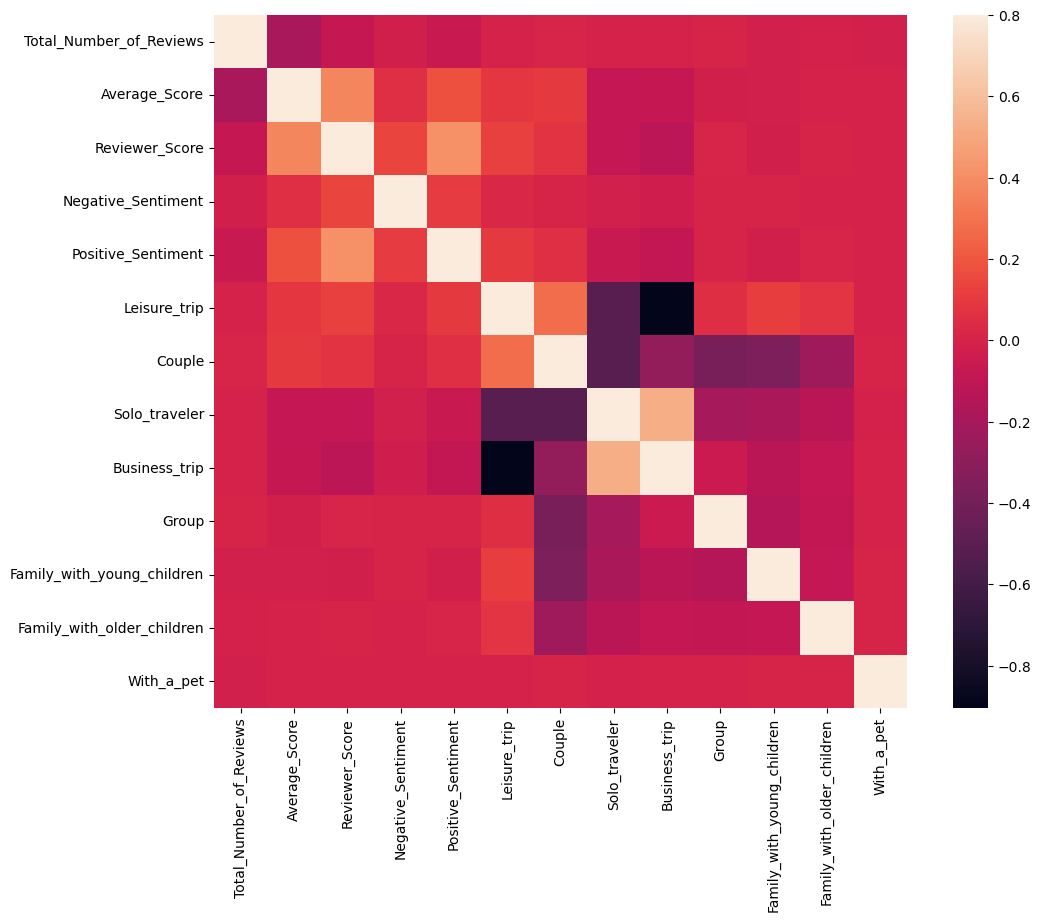

In [14]:
corrmat = df.corr(numeric_only=True)
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True)